# NoctiBand AI — One-Night Data Exploration

**Dataset:** PhysioNet BIDSleep v1.0.0  
**Recording inspected:** Bidslab00 / night 3  
**Purpose:** Inspect heart rate, expert sleep-stage labels, timestamps, coverage and data quality before machine-learning experiments.

The motion file is currently incomplete, so motion analysis is intentionally marked pending. No model is trained in this notebook.

Reference: https://physionet.org/content/bidsleep-dataset/1.0.0/


## A. Load the data

We use the original HR CSV and label MAT file. Paths are resolved relative to the project root, not the terminal's current directory.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "docs" / "PROJECT_SPEC.md").exists():
    ROOT = ROOT.parent

if not (ROOT / "docs" / "PROJECT_SPEC.md").exists():
    raise FileNotFoundError("Could not locate project root containing docs/PROJECT_SPEC.md")

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

hr_path = RAW / "hr.csv"
labels_path = RAW / "labels.mat"

hr = pd.read_csv(hr_path, header=None, names=["timestamp", "heart_rate"])
mat = loadmat(labels_path)
expert_labels = mat["expert_label"].ravel()
dreem_labels = mat["dreem_label"].ravel()

rec_start_text = str(mat["recStart"][0])
rec_start = pd.Timestamp(rec_start_text).tz_localize("America/New_York")
rec_start_unix = rec_start.timestamp()

print("Project root:", ROOT)
print("HR rows:", len(hr))
print("Expert labels:", len(expert_labels))
print("Automated labels:", len(dreem_labels))
print("Recording start:", rec_start)
print("HR missing values:")
print(hr.isna().sum())


Project root: c:\Users\Koushal\Desktop\NoctiBand_AI
HR rows: 5282
Expert labels: 993
Automated labels: 993
Recording start: 2021-12-04 23:40:29-05:00
HR missing values:
timestamp     0
heart_rate    0
dtype: int64


## B. Validate timestamps and coverage

Each label represents a 30-second epoch. Epoch IDs below are zero-based, so epoch 0 corresponds to the first label.

In [2]:
hr["time_utc"] = pd.to_datetime(hr["timestamp"], unit="s", utc=True)
hr["epoch"] = np.floor((hr["timestamp"] - rec_start_unix) / 30).astype(int)

window_start = rec_start_unix
window_end = window_start + 30 * len(expert_labels)
inside = hr["timestamp"].between(window_start, window_end, inclusive="left")

print("Label window start UTC:", pd.to_datetime(window_start, unit="s", utc=True))
print("Label window end UTC:", pd.to_datetime(window_end, unit="s", utc=True))
print("First HR UTC:", hr["time_utc"].min())
print("Last HR UTC:", hr["time_utc"].max())
print("HR readings before window:", int((hr["timestamp"] < window_start).sum()))
print("HR readings inside window:", int(inside.sum()))
print("HR readings after window:", int((hr["timestamp"] >= window_end).sum()))
print("HR readings with valid epoch IDs:", int(hr["epoch"].between(0, len(expert_labels)-1).sum()))


Label window start UTC: 2021-12-05 04:40:29+00:00
Label window end UTC: 2021-12-05 12:56:59+00:00
First HR UTC: 2021-12-05 04:38:54.078155041+00:00
Last HR UTC: 2021-12-05 12:55:29.000268459+00:00
HR readings before window: 16
HR readings inside window: 5266
HR readings after window: 0
HR readings with valid epoch IDs: 5266


## C. Inspect heart rate

This plot shows the original HR samples. Spikes are inspected rather than automatically removed.

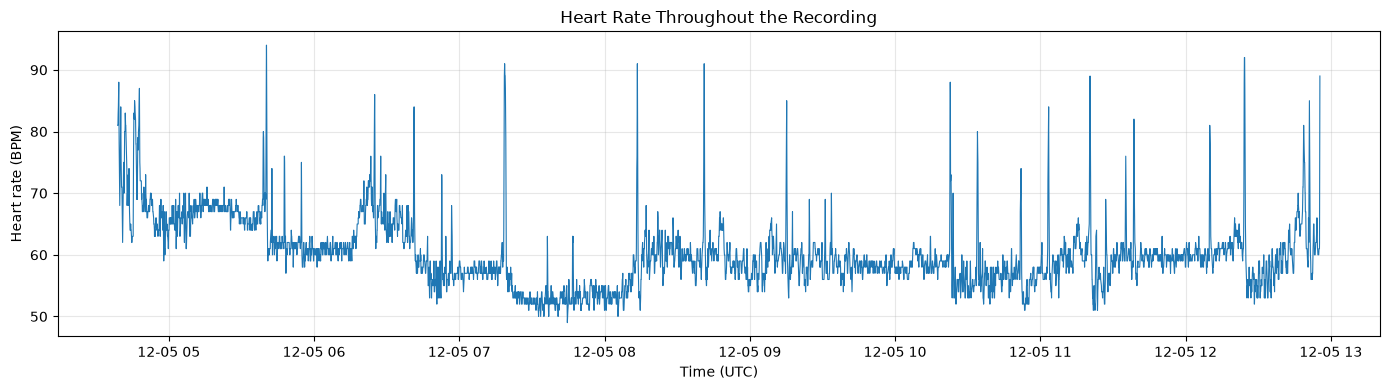

count    5282.000000
mean       60.098826
std         5.625207
min        49.000000
25%        57.000000
50%        59.000000
75%        62.000000
max        94.000000
Name: heart_rate, dtype: float64


In [3]:
plt.figure(figsize=(14, 4))
plt.plot(hr["time_utc"], hr["heart_rate"], linewidth=0.8)
plt.xlabel("Time (UTC)")
plt.ylabel("Heart rate (BPM)")
plt.title("Heart Rate Throughout the Recording")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "heart_rate.png", dpi=150)
plt.show()

print(hr["heart_rate"].describe())


## D. Inspect sleep-stage labels

Label codes: 0 = Wake, 1 = N1, 2 = N2, 3 = N3, 4 = REM, 5 = Unknown.

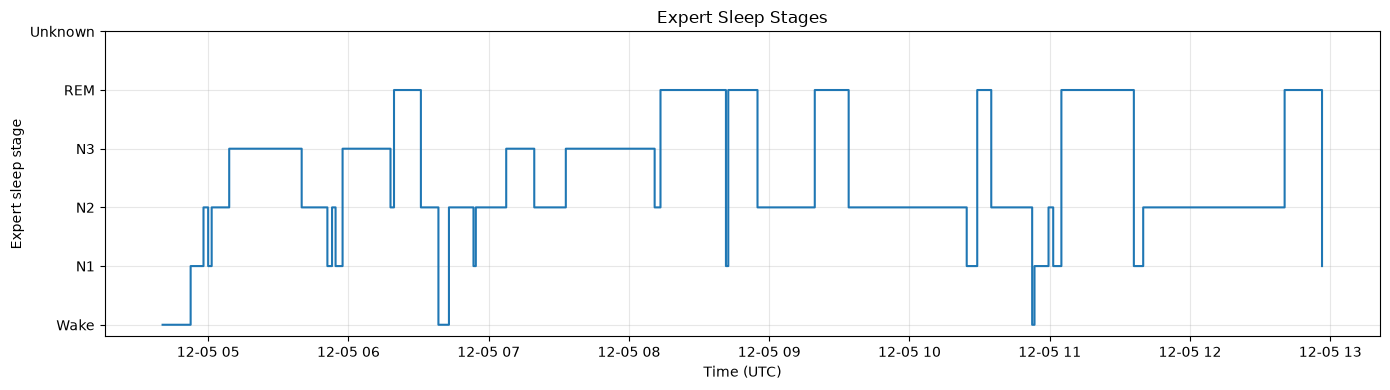

Expert label counts:
Wake     35
N1       65
N2      451
N3      203
REM     239
Name: count, dtype: int64
Total labeled epochs: 993


In [4]:
stage_names = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM", 5: "Unknown"}
label_times = pd.to_datetime(
    rec_start_unix + np.arange(len(expert_labels)) * 30,
    unit="s", utc=True
)

plt.figure(figsize=(14, 4))
plt.step(label_times, expert_labels, where="post")
plt.yticks(list(stage_names), [stage_names[x] for x in stage_names])
plt.xlabel("Time (UTC)")
plt.ylabel("Expert sleep stage")
plt.title("Expert Sleep Stages")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "sleep_stages.png", dpi=150)
plt.show()

counts = pd.Series(expert_labels).value_counts().sort_index()
print("Expert label counts:")
print(counts.rename(index=stage_names))
print("Total labeled epochs:", len(expert_labels))


## E. Build an epoch-level HR feature table

Each row represents one labeled 30-second epoch. Epochs without HR readings are retained with missing features rather than invented values.

In [5]:
valid_hr = hr.loc[hr["epoch"].between(0, len(expert_labels)-1)].copy()

features = valid_hr.groupby("epoch").agg(
    hr_count=("heart_rate", "count"),
    hr_mean=("heart_rate", "mean"),
    hr_median=("heart_rate", "median"),
    hr_std=("heart_rate", "std"),
    hr_min=("heart_rate", "min"),
    hr_max=("heart_rate", "max"),
    hr_first=("heart_rate", "first"),
    hr_last=("heart_rate", "last"),
)

features = features.reindex(range(len(expert_labels)))
features.index.name = "epoch"
features = features.reset_index()
features["sleep_stage"] = expert_labels
features["hr_range"] = features["hr_max"] - features["hr_min"]
features["hr_change"] = features["hr_last"] - features["hr_first"]

PROCESSED.mkdir(parents=True, exist_ok=True)
features.to_csv(PROCESSED / "epoch_features.csv", index=False)

print("Feature table shape:", features.shape)
print("Epochs without HR:", int(features["hr_count"].isna().sum()))
display(features.head(10))


Feature table shape: (993, 12)
Epochs without HR: 2


,epoch,hr_count,hr_mean,hr_median,hr_std,hr_min,hr_max,hr_first,hr_last,sleep_stage,hr_range,hr_change
0,0,4.0,66.500000,66.5,5.196152,62.0,71.0,71.0,62.0,0,9.0,-9.0
1,1,2.0,73.500000,73.5,2.121320,72.0,75.0,75.0,72.0,0,3.0,-3.0
2,2,5.0,76.200000,80.0,5.674504,70.0,81.0,70.0,81.0,0,11.0,11.0
3,3,3.0,81.666667,81.0,1.154701,81.0,83.0,83.0,81.0,0,2.0,-2.0
4,4,3.0,70.666667,70.0,3.055050,68.0,74.0,74.0,70.0,0,6.0,-4.0
5,5,5.0,70.600000,70.0,2.302173,68.0,73.0,70.0,68.0,0,5.0,-2.0
6,6,4.0,69.750000,70.0,4.425306,65.0,74.0,74.0,65.0,0,9.0,-9.0
7,7,8.0,64.125000,64.0,0.353553,64.0,65.0,64.0,64.0,0,1.0,0.0
8,8,4.0,62.500000,62.5,0.577350,62.0,63.0,63.0,63.0,0,1.0,0.0
9,9,7.0,66.142857,63.0,5.639993,63.0,77.0,63.0,77.0,0,14.0,14.0


## F. Missingness and signal-quality checks

In [6]:
print("Missing values by column:")
display(features.isna().sum().to_frame("missing_count"))

print("HR feature summary:")
display(features[["hr_count", "hr_mean", "hr_std", "hr_min", "hr_max"]].describe())

print("Epochs with no HR readings:")
display(features.loc[features["hr_count"].isna(), ["epoch", "sleep_stage"]])

print("Epochs with only one HR reading:")
display(features.loc[features["hr_count"].eq(1), ["epoch", "hr_count", "hr_mean", "sleep_stage"]])


Missing values by column:


,missing_count
epoch,0
hr_count,2
hr_mean,2
hr_median,2
hr_std,3
hr_min,2
hr_max,2
hr_first,2
hr_last,2
sleep_stage,0


HR feature summary:


,hr_count,hr_mean,hr_std,hr_min,hr_max
count,991.000000,991.000000,990.000000,991.000000,991.000000
mean,5.313824,60.097672,1.364152,58.612513,61.694248
std,1.047074,5.260940,1.695322,4.731498,6.217307
min,1.000000,50.500000,0.000000,49.000000,52.000000
25%,5.000000,56.833333,0.547723,56.000000,58.000000
50%,5.000000,59.333333,0.894427,58.000000,61.000000
75%,6.000000,61.833333,1.451441,61.000000,64.000000
max,8.000000,89.000000,14.679918,89.000000,94.000000


Epochs with no HR readings:


,epoch,sleep_stage
991,991,4
992,992,1


Epochs with only one HR reading:


,epoch,hr_count,hr_mean,sleep_stage
990,990,1.0,89.0,4


## G. Movement data status

The available `motion.csv.partial` is an incomplete download and must not be treated as a complete recording. Movement plots and acceleration features remain pending until the original motion file has been downloaded and verified.

In [7]:
motion_complete = RAW / "motion.csv"
motion_partial = RAW / "motion.csv.partial"

if motion_complete.exists():
    print("A motion.csv file exists. Verify its completeness and schema before analysis.")
elif motion_partial.exists():
    print("Motion analysis pending: only motion.csv.partial is present.")
    print("Partial file size:", motion_partial.stat().st_size, "bytes")
else:
    print("Motion analysis pending: motion file not found.")


Motion analysis pending: only motion.csv.partial is present.
Partial file size: 4161168 bytes


## H. Findings and limitations

- HR and expert labels are inspected separately.
- Epoch assignment follows the dataset's documented 30-second rule relative to `recStart`.
- HR samples outside the labeled time window are excluded from the epoch feature table.
- Missing HR features are retained as missing values.
- The HR recording boundaries differ from the label window; this is documented and no arbitrary timestamp shift is applied.
- Motion analysis remains incomplete until a verified full `motion.csv` is available.
- This is one night from one participant and is not sufficient to establish model generalization.
- No model is trained in this notebook.

**Next:** verify alignment and motion coverage, then process multiple participants/nights before subject-level model evaluation.


Total labeled epochs: 993
Epochs with HR available: 991

Wake/Sleep epoch counts:
group
Sleep    958
Wake      35

Wake/Sleep proportions:
group
Sleep    96.48%
Wake      3.52%

HR mean (BPM) by group:
       count   mean  median   std    min    max
group                                          
Sleep    956  59.79    59.2  4.89  50.50  89.00
Wake      35  68.44    68.2  7.70  52.33  83.33


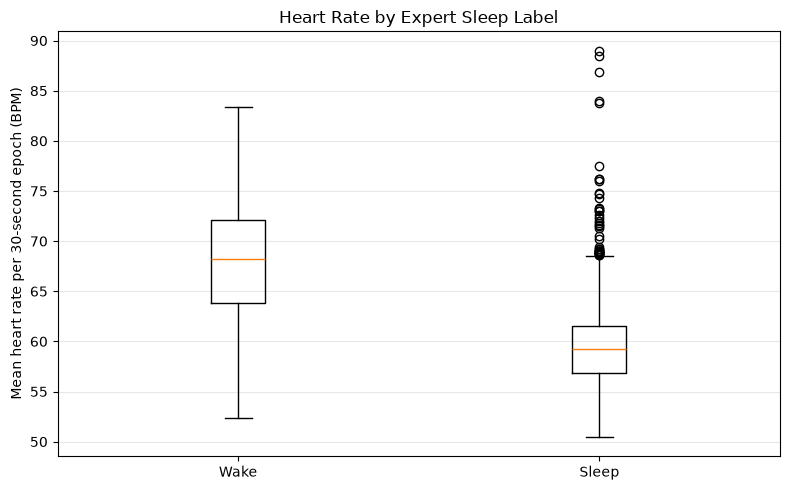


Saved figure: C:\Users\Koushal\Desktop\NoctiBand_AI\docs\figures\wake_vs_sleep_hr.png

Limitation: this compares HR only. Movement comparison is pending until a complete motion.csv is available.


In [8]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Locate the project root reliably
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "docs" / "PROJECT_SPEC.md"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "epoch_features.csv"
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load the existing epoch-level features
wake_sleep_df = pd.read_csv(FEATURES_PATH)

# Documented expert-label mapping:
# 0 = Wake, 1 = N1, 2 = N2, 3 = N3, 4 = REM
wake_sleep_df["group"] = wake_sleep_df["sleep_stage"].map(
    lambda label: "Wake" if label == 0 else "Sleep"
)

# Compare epochs with available mean heart-rate values
valid_hr_df = wake_sleep_df.dropna(subset=["hr_mean"]).copy()

print("Total labeled epochs:", len(wake_sleep_df))
print("Epochs with HR available:", len(valid_hr_df))
print("\nWake/Sleep epoch counts:")
print(wake_sleep_df["group"].value_counts().to_string())

print("\nWake/Sleep proportions:")
print(
    (wake_sleep_df["group"].value_counts(normalize=True) * 100)
    .round(2).astype(str).add("%").to_string()
)

print("\nHR mean (BPM) by group:")
print(
    valid_hr_df.groupby("group")["hr_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2).to_string()
)

# Create a comparison plot
groups = [
    valid_hr_df.loc[valid_hr_df["group"] == name, "hr_mean"].values
    for name in ["Wake", "Sleep"]
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(groups, tick_labels=["Wake", "Sleep"])
ax.set_title("Heart Rate by Expert Sleep Label")
ax.set_ylabel("Mean heart rate per 30-second epoch (BPM)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

output_path = FIGURES_DIR / "wake_vs_sleep_hr.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved figure:", output_path)
print(
    "\nLimitation: this compares HR only. Movement comparison is pending "
    "until a complete motion.csv is available."
)


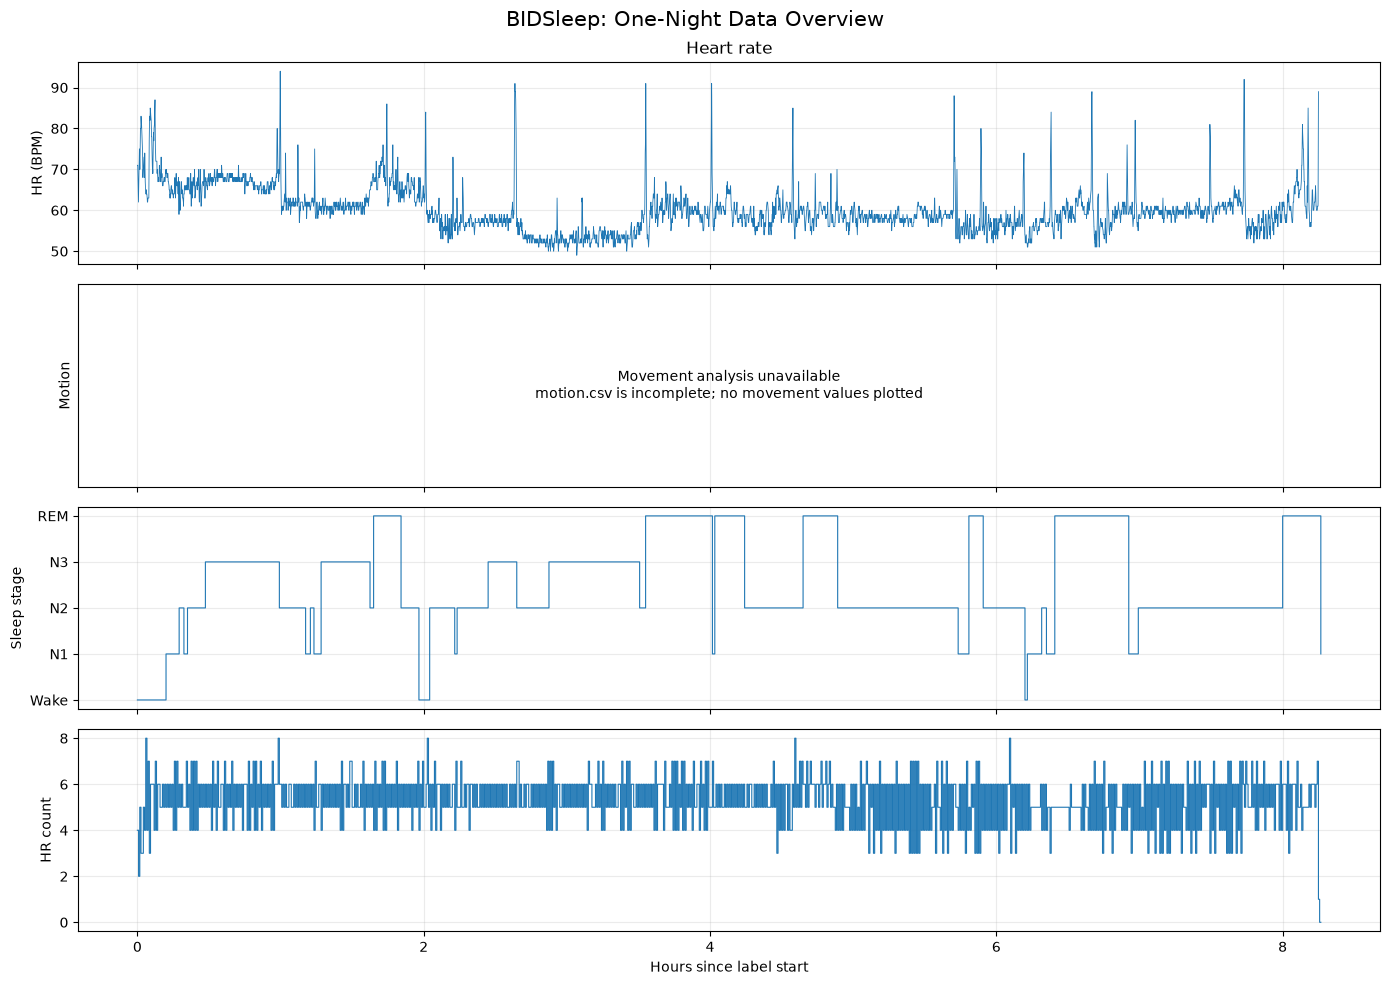

Saved overview: C:\Users\Koushal\Desktop\NoctiBand_AI\docs\figures\night_overview.png
Labeled epochs: 993
HR samples inside label window: 5266
Epochs without HR: 2
Motion panel is a limitation notice, not measured motion data.


In [9]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Find the project root
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "docs" / "PROJECT_SPEC.md").exists():
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Load source data and generated epoch features
hr = pd.read_csv(
    RAW / "hr.csv",
    header=None,
    names=["timestamp", "heart_rate"]
)
mat = loadmat(RAW / "labels.mat")
labels = mat["expert_label"].ravel()

rec_start = pd.Timestamp(
    str(mat["recStart"][0])
).tz_localize("America/New_York").timestamp()

features = pd.read_csv(PROCESSED / "epoch_features.csv")
n_epochs = len(labels)

# Keep only HR samples inside the labeled window
label_end = rec_start + 30 * n_epochs
hr = hr[(hr["timestamp"] >= rec_start) & (hr["timestamp"] < label_end)].copy()
hr["hours"] = (hr["timestamp"] - rec_start) / 3600

epoch_hours = np.arange(n_epochs) * 30 / 3600
hr_counts = (
    features.set_index("epoch")["hr_count"]
    .reindex(range(n_epochs), fill_value=0)
    .fillna(0)
    .to_numpy()
)

# Four panels: HR, motion status, sleep stages, and HR coverage
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(hr["hours"], hr["heart_rate"], linewidth=0.6)
axes[0].set_ylabel("HR (BPM)")
axes[0].set_title("Heart rate")

axes[1].text(
    0.5, 0.5,
    "Movement analysis unavailable\n"
    "motion.csv is incomplete; no movement values plotted",
    ha="center", va="center",
    transform=axes[1].transAxes
)
axes[1].set_ylabel("Motion")
axes[1].set_yticks([])

axes[2].step(epoch_hours, labels, where="post", linewidth=0.8)
axes[2].set_ylabel("Sleep stage")
axes[2].set_yticks([0, 1, 2, 3, 4])
axes[2].set_yticklabels(["Wake", "N1", "N2", "N3", "REM"])

axes[3].step(epoch_hours, hr_counts, where="post", linewidth=0.8)
axes[3].set_ylabel("HR count")
axes[3].set_xlabel("Hours since label start")

for ax in axes:
    ax.grid(alpha=0.25)

fig.suptitle("BIDSleep: One-Night Data Overview", fontsize=15)
fig.tight_layout()

output = FIGURES / "night_overview.png"
fig.savefig(output, dpi=150, bbox_inches="tight")
plt.show()

print("Saved overview:", output)
print("Labeled epochs:", n_epochs)
print("HR samples inside label window:", len(hr))
print("Epochs without HR:", int((hr_counts == 0).sum()))
print("Motion panel is a limitation notice, not measured motion data.")
